In [3]:
pip install ppscore

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13215 sha256=41e22d9572dc75086b2ccd825ce6aacaacee43f84637ee3b86b9c05289f47185
  Stored in directory: c:\users\midhu\appdata\local\pip\cache\wheels\84\0d\d6\ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# Outlier detection
from sklearn.ensemble import IsolationForest

# PPS Score
import ppscore as pps

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Load dataset
df = pd.read_csv("adult_with_headers.csv")

# Display first 5 rows
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [11]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


In [13]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')


In [15]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [17]:
print(df.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [19]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [21]:
df.replace(" ?", np.nan, inplace=True)

In [23]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [25]:
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)

In [27]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

Categorical Columns:
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [29]:
standard_scaler = StandardScaler()

df_standard_scaled = df.copy()

df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(df[numerical_cols])

print(df_standard_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.030671          State-gov -1.063611   Bachelors       1.134739   
1  0.837109   Self-emp-not-inc -1.008707   Bachelors       1.134739   
2 -0.042642            Private  0.245079     HS-grad      -0.420060   
3  1.057047            Private  0.425801        11th      -1.197459   
4 -0.775768            Private  1.408176   Bachelors       1.134739   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0      0.148453      -0.21

In [31]:
minmax_scaler = MinMaxScaler()

df_minmax_scaled = df.copy()

df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(df[numerical_cols])

print(df_minmax_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.301370          State-gov  0.044302   Bachelors       0.800000   
1  0.452055   Self-emp-not-inc  0.048238   Bachelors       0.800000   
2  0.287671            Private  0.138113     HS-grad       0.533333   
3  0.493151            Private  0.151068        11th       0.400000   
4  0.150685            Private  0.221488   Bachelors       0.800000   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0       0.02174           

In [33]:
small_cat_cols = []

for col in categorical_cols:
    if df[col].nunique() < 5:
        small_cat_cols.append(col)

print(small_cat_cols)

['sex', 'income']


In [35]:
df = pd.get_dummies(df, columns=small_cat_cols)

print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race  \
0        Never-married        Adm-clerical   Not-in-family   White   
1   Married-civ-spouse     Exec-managerial         Husband   White   
2             Divorced   Handlers-cleaners   Not-in-family   White   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black   
4   Married-civ-spouse      Prof-specialty            Wife   Black   

   capital_gain  capital_loss  hours_per_week  native_country  sex_ Female  \
0          2174             0              40   United-States        False   
1             0             0         

In [37]:
label_encoder = LabelEncoder()

large_cat_cols = []

for col in categorical_cols:
    if col not in small_cat_cols:
        large_cat_cols.append(col)

print(large_cat_cols)

['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [39]:
for col in large_cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          9             13               4   
1   50          5   83311          9             13               2   
2   38          3  215646         11              9               0   
3   53          3  234721          1              7               2   
4   28          3  338409          9             13               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           0             1     4          2174             0              40   
1           3             0     4             0             0              13   
2           5             1     4             0             0              40   
3           5             0     2             0             0              40   
4           9             5     2             0             0              40   

   native_country  sex_ Female  sex_ Male  income_ <=50K  income_ >50K  
0            

In [49]:
df['Net_Capital'] = df['capital_gain'] - df['capital_loss']
df['Hours_per_Age'] = df['hours_per_week'] / df['age']

In [51]:
print(df[numerical_cols].skew())

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64


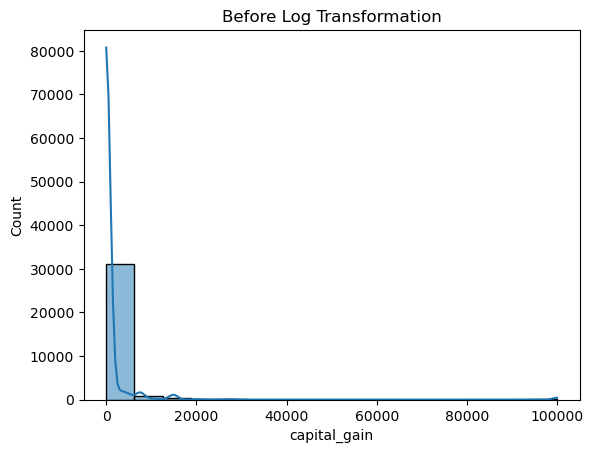

In [55]:
sns.histplot(df['capital_gain'], kde=True)
plt.title("Before Log Transformation")
plt.show()

In [57]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

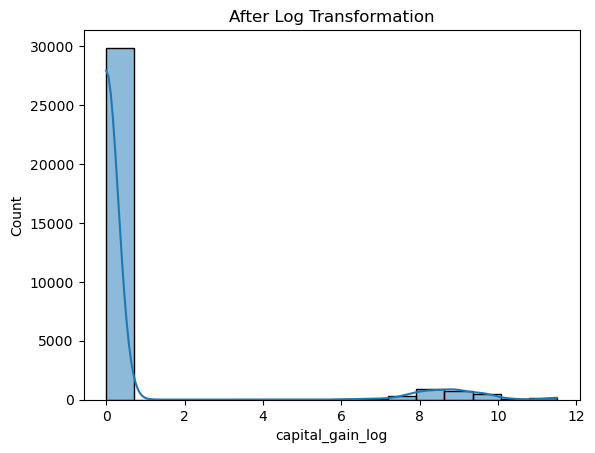

In [59]:
sns.histplot(df['capital_gain_log'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [61]:
iso = IsolationForest(contamination=0.05)

outliers = iso.fit_predict(df[numerical_cols])

df['Outlier'] = outliers

In [63]:
print(df['Outlier'].value_counts())

Outlier
 1    30933
-1     1628
Name: count, dtype: int64


In [65]:
df_cleaned = df[df['Outlier'] == 1]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_cleaned.shape)

Original Shape: (32561, 21)
Cleaned Shape: (30933, 21)


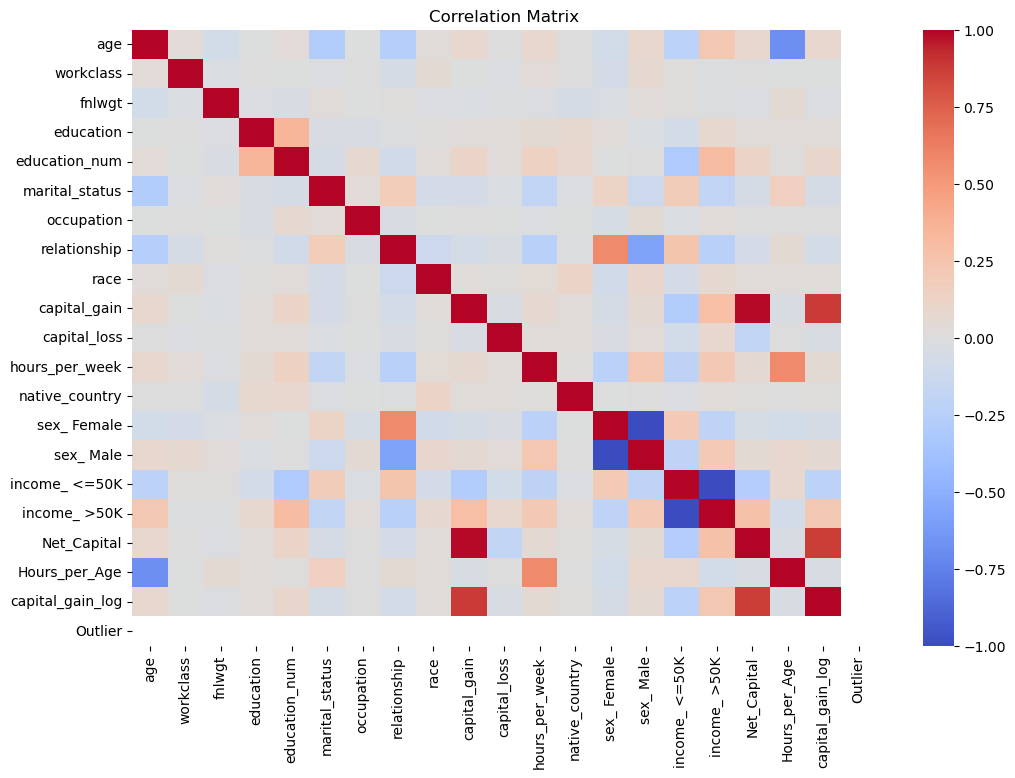

In [67]:
plt.figure(figsize=(12,8))

sns.heatmap(df_cleaned.corr(), cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [69]:
pps_matrix = pps.matrix(df_cleaned)

print(pps_matrix.head())

     x              y  ppscore            case  is_valid_score  \
0  age            age      1.0  predict_itself            True   
1  age      workclass      0.0      regression            True   
2  age         fnlwgt      0.0      regression            True   
3  age      education      0.0      regression            True   
4  age  education_num      0.0      regression            True   

                metric  baseline_score   model_score                    model  
0                 None          0.0000      1.000000                     None  
1  mean absolute error          0.5198      0.605309  DecisionTreeRegressor()  
2  mean absolute error      74561.6398  75814.451285  DecisionTreeRegressor()  
3  mean absolute error          2.6974      2.735669  DecisionTreeRegressor()  
4  mean absolute error          1.7782      1.801441  DecisionTreeRegressor()  


In [70]:
pps_score = pps_matrix[['x', 'y', 'ppscore']]

pps_score = pps_score.sort_values(by='ppscore', ascending=False)

print(pps_score.head(20))

                  x               y  ppscore
0               age             age      1.0
44           fnlwgt          fnlwgt      1.0
67        education   education_num      1.0
87    education_num       education      1.0
88    education_num   education_num      1.0
110  marital_status  marital_status      1.0
132      occupation      occupation      1.0
154    relationship    relationship      1.0
176            race            race      1.0
198    capital_gain    capital_gain      1.0
242  hours_per_week  hours_per_week      1.0
264  native_country  native_country      1.0
286     sex_ Female     sex_ Female      1.0
287     sex_ Female       sex_ Male      1.0
307       sex_ Male     sex_ Female      1.0
308       sex_ Male       sex_ Male      1.0
330   income_ <=50K   income_ <=50K      1.0
331   income_ <=50K    income_ >50K      1.0
351    income_ >50K   income_ <=50K      1.0
352    income_ >50K    income_ >50K      1.0


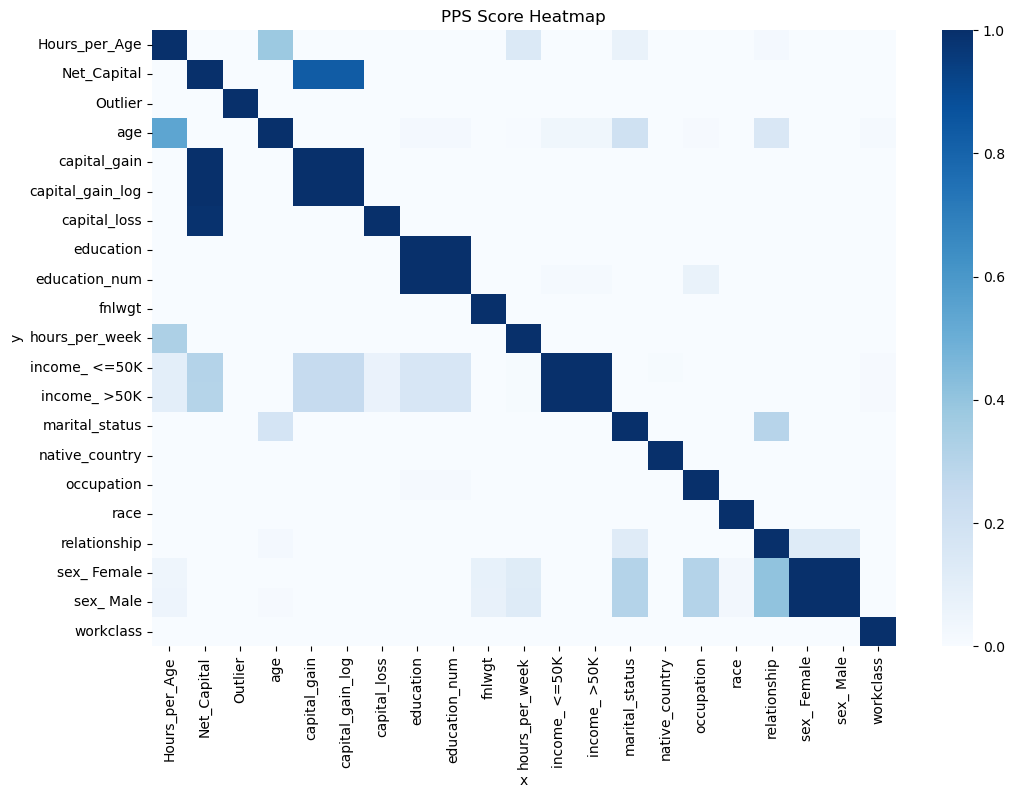

In [71]:
pivot_table = pps_matrix.pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize=(12,8))

sns.heatmap(pivot_table, annot=False, cmap='Blues')

plt.title("PPS Score Heatmap")

plt.show()